In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from tensorflow.keras import Sequential
from tensorflow import keras
from keras.layers import Dropout, Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.optimizers import Adam
import statistics

In [2]:
print('Inicio:',datetime.now())

Inicio: 2026-06-13 11:18:54.779243


In [3]:
# Lectura de datasets 
nilo=pd.read_csv("../Notebooks enfermedades/nilo_it_indexado.csv", sep=",",index_col=0) 
humedad=pd.read_csv("../Notebooks meteorologia/humedad_mensual_ita.csv", sep=",",index_col=0) 
temperatura=pd.read_csv("../Notebooks meteorologia/temperatura_mensual_ita.csv", sep=",",index_col=0) 
viento=pd.read_csv("../Notebooks meteorologia/viento_mensual_ita.csv", sep=",",index_col=0) 
precipitaciones=pd.read_csv("../Notebooks meteorologia/precipitaciones_mensuales_ita.csv", sep=",",index_col=0) 
trends_mosquito=pd.read_csv("../Notebooks google trends/mosquito_it_trends.csv", sep=",",index_col=0)

In [4]:
# Unificación de datasets
nilo_tot=pd.concat([nilo,temperatura,humedad,viento,precipitaciones,trends_mosquito],axis=1)
nilo_tot.index = pd.to_datetime(nilo_tot.index)
df=nilo_tot.dropna()

In [5]:
#Incluimos variables númericas para los meses 
df['mes']=df.index.month
df

,NumValue,TG,HU,FG,RR,mosquito_it_trends,mes
2008-01-01,0.0,77.645161,83.343280,27.265233,17.935484,168,1
2008-02-01,0.0,78.436782,74.284483,26.729885,7.827586,190,2
2008-03-01,0.0,109.225806,74.237615,36.734767,25.861042,275,3
2008-04-01,0.0,139.600000,71.183333,35.451852,25.825000,229,4
2008-05-01,0.0,183.473118,71.419355,29.865591,33.104839,250,5
...,...,...,...,...,...,...,...
2023-08-01,183.0,255.838710,63.250000,30.944444,17.536290,307,8
2023-09-01,75.0,232.666667,67.841667,30.505556,12.345833,226,9
2023-10-01,18.0,198.327957,75.032258,31.277778,29.229839,224,10
2023-11-01,4.0,124.280268,77.958333,35.837963,25.387500,94,11


In [6]:
df.corr(method='pearson')

,NumValue,TG,HU,FG,RR,mosquito_it_trends,mes
NumValue,1.000000,0.359088,-0.257526,-0.137653,-0.057874,0.409350,0.123484
TG,0.359088,1.000000,-0.662492,-0.480157,-0.184205,0.861730,0.276293
HU,-0.257526,-0.662492,1.000000,0.216513,0.529042,-0.676856,0.213326
FG,-0.137653,-0.480157,0.216513,1.000000,0.343720,-0.384826,-0.330075
RR,-0.057874,-0.184205,0.529042,0.343720,1.000000,-0.286818,0.133045
mosquito_it_trends,0.409350,0.861730,-0.676856,-0.384826,-0.286818,1.000000,0.077666
mes,0.123484,0.276293,0.213326,-0.330075,0.133045,0.077666,1.000000


Función de normalización

In [7]:
def split_data(df,test_split=0.1):
    n=int(len(df)*test_split)
    train,test=df[:-n],df[-n:]
    return train, test

### GRU con todas las variables

In [8]:
train1,test1=split_data(df)

In [9]:
from sklearn.preprocessing import MinMaxScaler
norm=MinMaxScaler()
train_norm1=pd.DataFrame(norm.fit_transform(train1),index=train1.index,columns=train1.columns)
test_norm1=pd.DataFrame(norm.transform(test1),index=test1.index,columns=test1.columns)

In [10]:
xtrainN1=train_norm1.iloc[:,1:]
xtestN1=test_norm1.iloc[:,1:]
ytrainN1=train_norm1.iloc[:,0]
ytestN1=test_norm1.iloc[:,0]
xtrainN1.shape

(173, 6)

In [11]:
xtrainN1,xvalN1=split_data(xtrainN1)
ytrainN1,yvalN1=split_data(ytrainN1)

### GRU (Adam lr=0.005, units=32, batch_size=64)

In [50]:
Y_gru12=pd.DataFrame(ytestN1,index=ytestN1.index).rename({'NumValue':'ytest'},axis=1)
for i in range(4):
    gru12 = Sequential()
    gru12.add(GRU(32, activation='relu', input_shape=(len(xtrainN1.columns), 1)))
    gru12.add(Dropout(0.1))
    gru12.add(Dense(1))
    gru12.compile(optimizer=Adam(learning_rate=0.005), loss='mse')
    gru12.fit(xtrainN1, ytrainN1, batch_size=64, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN1,yvalN1))
    ypred_gru12=gru12.predict(xtestN1)
    Y_gru12['ypred_'+str(i)]=pd.DataFrame(ypred_gru12,index=ytestN1.index)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 205ms/step - loss: 0.0105 - val_loss: 0.0012
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0083 - val_loss: 0.0041
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0097 - val_loss: 9.9285e-04
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0076 - val_loss: 9.6911e-04
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0073 - val_loss: 7.9684e-04
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0072 - val_loss: 8.6631e-04
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0075 - val_loss: 0.0015
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0076 - val_loss: 0.0011
Epoch 9/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0080 - val_loss: 7.0935e-04
Epoch 10/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0074 - val_loss: 6.6211e-04
Epoch 11/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0072 - val_loss: 6.6449e-04
Epoch 12/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms

In [51]:
Y_gru12['ypred_T']=0
for i in range(0,Y_gru12.shape[0]):
    Y_gru12['ypred_T'][i]=(Y_gru12['ypred_0'][i]+Y_gru12['ypred_1'][i]+Y_gru12['ypred_2'][i]+Y_gru12['ypred_3'][i])/4

Y_gru12

,ytest,ypred_0,ypred_1,ypred_2,ypred_3,ypred_T
2022-06-01,0.011730,0.013733,0.009321,0.022273,0.016019,0.015337
2022-07-01,0.639296,0.031347,0.009721,0.194216,0.027348,0.065658
2022-08-01,1.146628,1.106769,0.593800,0.372543,1.069914,0.785757
2022-09-01,0.284457,0.105317,0.025729,0.033326,0.027573,0.047986
2022-10-01,0.043988,0.114043,0.026710,0.038993,0.060501,0.060062
2022-11-01,0.005865,0.009300,0.009215,0.001519,0.012371,0.008101
2022-12-01,0.000000,0.010241,0.014968,0.016475,0.009671,0.012839
2023-01-01,0.000000,-0.001210,0.003589,-0.001037,0.004668,0.001503
2023-02-01,0.000000,0.003618,0.002386,-0.002356,0.008692,0.003085
2023-03-01,0.000000,0.005804,0.003638,-0.000026,0.008682,0.004525


In [52]:
y12=r2_score(Y_gru12.iloc[:,0], Y_gru12.iloc[:,5])
n12=mean_squared_error(Y_gru12.iloc[:,0], Y_gru12.iloc[:,5])
d12=mean_absolute_error(Y_gru12.iloc[:,0], Y_gru12.iloc[:,5])

print(y12)
print(n12)
print(d12)

0.5113744522205668
0.042709454058365286
0.1113540289046993


### Cálculo de la ventana deslizante lag 4 todas 

In [15]:
def one_step_forecast(df, window):
    d = df.values
    x = []
    n = len(df)
    idx = df.index[:-window]
    for start in range(n-window):
        end = start + window
        x.append(d[start:end])
    cols = [f'x_{i}' for i in range(1, window+1)]
    x = np.array(x).reshape(n-window, -1)
    y = df.iloc[window:].values
    df_xs = pd.DataFrame(x, columns=cols, index=idx)
    df_y = pd.DataFrame(y.reshape(-1), columns=['y'], index=idx)
    return pd.concat([df_y,df_xs], axis=1).dropna()

In [16]:
df_inf=one_step_forecast(df.iloc[:,0],4) #ventana deslizante de infectados
df_temp=one_step_forecast(df.iloc[:,1],4).iloc[:,1:].rename({'x_1':'x_1_temp','x_2':'x_2_temp','x_3':'x_3_temp','x_4':'x_4_temp'},axis=1)
df_hum=one_step_forecast(df.iloc[:,2],4).iloc[:,1:].rename({'x_1':'x_1_hum','x_2':'x_2_hum','x_3':'x_3_hum','x_4':'x_4_hum'},axis=1)
df_wind=one_step_forecast(df.iloc[:,3],4).iloc[:,1:].rename({'x_1':'x_1_wind','x_2':'x_2_wind','x_3':'x_3_wind','x_4':'x_4_wind'},axis=1)
df_prep=one_step_forecast(df.iloc[:,4],4).iloc[:,1:].rename({'x_1':'x_1_prep','x_2':'x_2_prep','x_3':'x_3_prep','x_4':'x_4_prep'},axis=1)
df_trend=one_step_forecast(df.iloc[:,5],4).iloc[:,1:].rename({'x_1':'x_1_tre','x_2':'x_2_tre','x_3':'x_3_tre','x_4':'x_4_tre'},axis=1)
df_mes=one_step_forecast(df.iloc[:,6],4).iloc[:,1:].rename({'x_1':'x_1_mes','x_2':'x_2_mes','x_3':'x_3_mes','x_4':'x_4_mes'},axis=1)

In [17]:
df2=pd.concat([df_inf.iloc[:,:2],df_temp.iloc[:,0],df_hum.iloc[:,0],df_wind.iloc[:,0],df_prep.iloc[:,0],df_trend.iloc[:,0],df_mes.iloc[:,0],
              df_inf.iloc[:,2],df_temp.iloc[:,1],df_hum.iloc[:,1],df_wind.iloc[:,1],df_prep.iloc[:,1],df_trend.iloc[:,1],df_mes.iloc[:,1],
              df_inf.iloc[:,3],df_temp.iloc[:,2],df_hum.iloc[:,2],df_wind.iloc[:,2],df_prep.iloc[:,2],df_trend.iloc[:,2],df_mes.iloc[:,2],
              df_inf.iloc[:,4],df_temp.iloc[:,3],df_hum.iloc[:,3],df_wind.iloc[:,3],df_prep.iloc[:,3],df_trend.iloc[:,3],df_mes.iloc[:,3]],axis=1)
df2

,y,x_1,x_1_temp,x_1_hum,x_1_wind,x_1_prep,x_1_tre,x_1_mes,x_2,x_2_temp,...,x_3_prep,x_3_tre,x_3_mes,x_4,x_4_temp,x_4_hum,x_4_wind,x_4_prep,x_4_tre,x_4_mes
2008-01-01,0.0,0.0,77.645161,83.343280,27.265233,17.935484,168,1,0.0,78.436782,...,25.861042,275,3,0.0,139.600000,71.183333,35.451852,25.825000,229,4
2008-02-01,0.0,0.0,78.436782,74.284483,26.729885,7.827586,190,2,0.0,109.225806,...,25.825000,229,4,0.0,183.473118,71.419355,29.865591,33.104839,250,5
2008-03-01,0.0,0.0,109.225806,74.237615,36.734767,25.861042,275,3,0.0,139.600000,...,33.104839,250,5,0.0,224.272222,72.091667,25.055556,22.691667,394,6
2008-04-01,0.0,0.0,139.600000,71.183333,35.451852,25.825000,229,4,0.0,183.473118,...,22.691667,394,6,0.0,252.553763,61.951613,28.964158,13.483871,271,7
2008-05-01,1.0,0.0,183.473118,71.419355,29.865591,33.104839,250,5,0.0,224.272222,...,13.483871,271,7,0.0,254.806452,62.000000,27.037634,9.564516,283,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-04-01,183.0,0.0,130.137125,67.325000,33.748148,14.375000,165,4,1.0,179.238889,...,17.929167,319,6,63.0,270.274194,67.346774,31.193122,16.120968,422,7
2023-05-01,75.0,1.0,179.238889,76.314516,30.621795,66.899194,204,5,0.0,215.644444,...,16.120968,422,7,183.0,255.838710,63.250000,30.944444,17.536290,307,8
2023-06-01,18.0,0.0,215.644444,67.408333,26.994709,17.929167,319,6,63.0,270.274194,...,17.536290,307,8,75.0,232.666667,67.841667,30.505556,12.345833,226,9
2023-07-01,4.0,63.0,270.274194,67.346774,31.193122,16.120968,422,7,183.0,255.838710,...,12.345833,226,9,18.0,198.327957,75.032258,31.277778,29.229839,224,10


### Normalización y separación en test y train

In [18]:
train2,test2=split_data(df2)

In [19]:
from sklearn.preprocessing import MinMaxScaler
norm=MinMaxScaler()
train_norm2=pd.DataFrame(norm.fit_transform(train2),index=train2.index,columns=train2.columns)
test_norm2=pd.DataFrame(norm.transform(test2),index=test2.index,columns=test2.columns)

In [20]:
xtrainN2=train_norm2.iloc[:,1:]
xtestN2=test_norm2.iloc[:,1:]
ytrainN2=train_norm2.iloc[:,0]
ytestN2=test_norm2.iloc[:,0]
xtrainN2.shape

(170, 28)

### Random Forest (Bootstrap=True)

In [21]:
rf_b=RandomForestRegressor(random_state=0,bootstrap=False)
rf_b.fit(xtrainN2,ytrainN2)
ypred=rf_b.predict(xtestN2.values.astype(np.float32))
Y_rf_b=pd.DataFrame(ytestN2,index=ytestN2.index).rename({'y':'ytest'},axis=1)
Y_rf_b['ypred']=pd.DataFrame(ypred,index=ytestN2.index)
#Y_rf_b

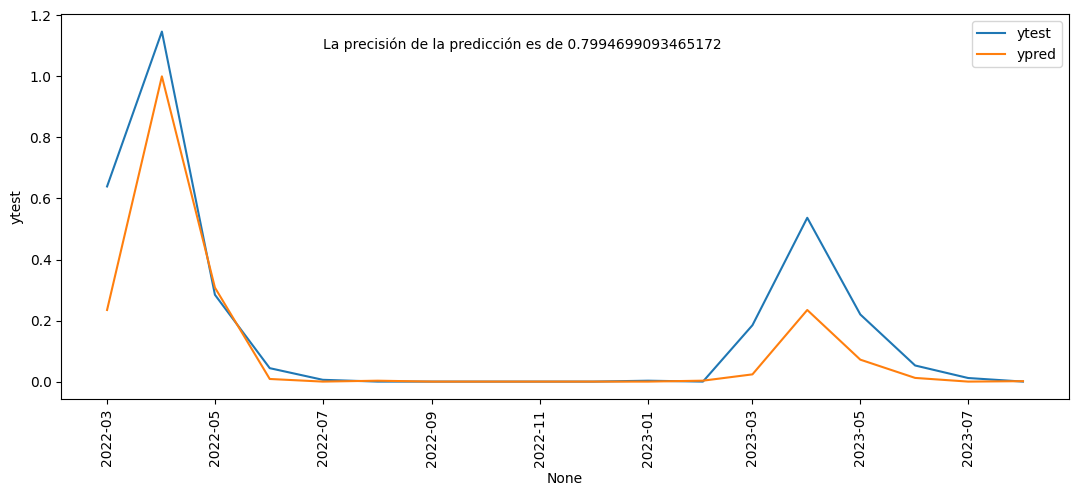

In [22]:
plt.figure(figsize=(13,5))
sns.lineplot(data=Y_rf_b,x=Y_rf_b.index,y=Y_rf_b.ytest,label='ytest')
sns.lineplot(data=Y_rf_b,x=Y_rf_b.index,y=Y_rf_b.ypred,label='ypred')
plt.legend()
plt.xticks(rotation=90)
plt.text(datetime(2022, 7, 1), 0.95*max(Y_rf_b.ytest), 'La precisión de la predicción es de '+str(r2_score(Y_rf_b.ytest, Y_rf_b.ypred)), fontsize=10)
plt.show()

### lag 4 variables seleccionadas

In [23]:
df3=pd.concat([df_inf.iloc[:,:2],df_temp.iloc[:,0],df_trend.iloc[:,0],df_inf.iloc[:,2],
              df_temp.iloc[:,1],df_trend.iloc[:,1],df_inf.iloc[:,3],df_temp.iloc[:,2],
              df_trend.iloc[:,2],df_inf.iloc[:,4],df_temp.iloc[:,3],df_trend.iloc[:,3]],axis=1)
df3

,y,x_1,x_1_temp,x_1_tre,x_2,x_2_temp,x_2_tre,x_3,x_3_temp,x_3_tre,x_4,x_4_temp,x_4_tre
2008-01-01,0.0,0.0,77.645161,168,0.0,78.436782,190,0.0,109.225806,275,0.0,139.600000,229
2008-02-01,0.0,0.0,78.436782,190,0.0,109.225806,275,0.0,139.600000,229,0.0,183.473118,250
2008-03-01,0.0,0.0,109.225806,275,0.0,139.600000,229,0.0,183.473118,250,0.0,224.272222,394
2008-04-01,0.0,0.0,139.600000,229,0.0,183.473118,250,0.0,224.272222,394,0.0,252.553763,271
2008-05-01,1.0,0.0,183.473118,250,0.0,224.272222,394,0.0,252.553763,271,0.0,254.806452,283
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-04-01,183.0,0.0,130.137125,165,1.0,179.238889,204,0.0,215.644444,319,63.0,270.274194,422
2023-05-01,75.0,1.0,179.238889,204,0.0,215.644444,319,63.0,270.274194,422,183.0,255.838710,307
2023-06-01,18.0,0.0,215.644444,319,63.0,270.274194,422,183.0,255.838710,307,75.0,232.666667,226
2023-07-01,4.0,63.0,270.274194,422,183.0,255.838710,307,75.0,232.666667,226,18.0,198.327957,224


In [24]:
train3,test3=split_data(df3)

In [25]:
from sklearn.preprocessing import MinMaxScaler
norm3=MinMaxScaler()
train_norm3=pd.DataFrame(norm3.fit_transform(train3),index=train3.index,columns=train3.columns)
test_norm3=pd.DataFrame(norm3.transform(test3),index=test3.index,columns=test3.columns)

In [26]:
xtrainN3=train_norm3.iloc[:,1:]
xtestN3=test_norm3.iloc[:,1:]
ytrainN3=train_norm3.iloc[:,0]
ytestN3=test_norm3.iloc[:,0]
xtrainN3.shape

(170, 12)

In [27]:
#Separación en validación y train
xtrainN3,xvalN3=split_data(xtrainN3)
ytrainN3,yvalN3=split_data(ytrainN3)

### GRU(Adam lr=0.003, units=64, batch_size=32)

In [28]:
Y_gru2=pd.DataFrame(ytestN3,index=ytestN3.index).rename({'y':'ytest'},axis=1)
for i in range(4):
    gru2 = Sequential()
    gru2.add(GRU(64, activation='relu', input_shape=(len(xtrainN3.columns), 1)))
    gru2.add(Dropout(0.1))
    gru2.add(Dense(1))
    gru2.compile(optimizer=Adam(learning_rate=0.003), loss='mse')
    gru2.fit(xtrainN3, ytrainN3, batch_size=32, epochs=500, verbose=1,shuffle=False,validation_data=(xvalN3,yvalN3))
    ypred_gru2=gru2.predict(xtestN3)
    Y_gru2['ypred_'+str(i)]=pd.DataFrame(ypred_gru2,index=ytestN3.index)

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0060 - val_loss: 0.0014
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0056 - val_loss: 4.6521e-04
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0051 - val_loss: 6.6910e-04
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0048 - val_loss: 9.0109e-04
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0049 - val_loss: 7.1716e-04
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0052 - val_loss: 7.1471e-04
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0047 - val_loss: 8.0907e-04
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0048 - val_loss: 8.6880e-04
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0044 - val_loss: 8.0492e-04
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0046 - val_loss: 8.4190e-04
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0049 - val_loss: 8.0541e-04
Epoch 12/500
5/5 ━━━━━━━━━━━━━━━━

In [34]:
Y_gru2['ypred_T']=0
for i in range(0,Y_gru2.shape[0]):
    Y_gru2['ypred_T'][i]=(Y_gru2['ypred_0'][i]+Y_gru2['ypred_1'][i]+Y_gru2['ypred_2'][i]+Y_gru2['ypred_3'][i])/4

Y_gru2

,ytest,ypred_0,ypred_1,ypred_2,ypred_3,ypred_T
2022-07-01,0.639296,0.668385,0.074761,0.282499,0.309319,0.333741
2022-08-01,1.146628,1.038609,1.165641,1.209729,1.099384,1.128341
2022-09-01,0.284457,0.332516,0.246148,0.302116,0.353538,0.308580
2022-10-01,0.043988,0.017424,0.037485,0.022139,0.022811,0.024965
2022-11-01,0.005865,-0.000894,0.020712,0.009312,-0.005094,0.006009
2022-12-01,0.000000,-0.002172,0.002731,-0.006260,0.001350,-0.001088
2023-01-01,0.000000,-0.000994,0.001133,-0.006194,0.007483,0.000357
2023-02-01,0.000000,-0.000714,0.000743,-0.005724,0.011544,0.001462
2023-03-01,0.000000,-0.001184,0.000596,-0.004553,0.012470,0.001832
2023-04-01,0.000000,-0.000713,-0.000515,-0.004526,0.007939,0.000546


In [35]:
v3=r2_score(Y_gru2.iloc[:,0], Y_gru2.iloc[:,5])
a3=mean_squared_error(Y_gru2.iloc[:,0], Y_gru2.iloc[:,5])
k3=mean_absolute_error(Y_gru2.iloc[:,0], Y_gru2.iloc[:,5])

print(v3)
print(k3)
print(a3)

0.9160841400505924
0.04139340512681101
0.007626293401286968


In [36]:
Y_rf_b=Y_rf_b.set_index(Y_gru12.iloc[1:,:].index)

In [37]:
Y_gru2=Y_gru2.set_index(Y_gru12.iloc[1:,:].index)

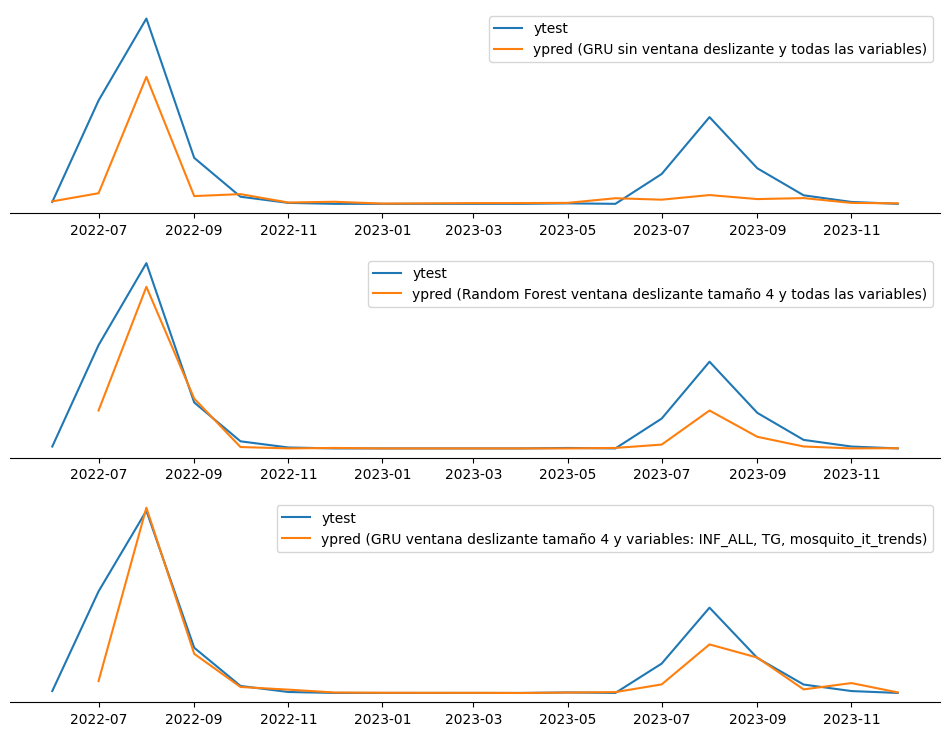

In [53]:
fig,ax=plt.subplots(3,1,figsize=(12,9))
sns.lineplot(data=Y_gru12,x=Y_gru12.index,y=Y_gru12.ytest,label='ytest',ax=ax[0])
sns.lineplot(data=Y_gru12,x=Y_gru12.index,y=Y_gru12.ypred_T,label='ypred (GRU sin ventana deslizante y todas las variables)',ax=ax[0])
sns.lineplot(data=Y_gru12,x=Y_gru12.index,y=Y_gru12.ytest,label='ytest',ax=ax[1])
sns.lineplot(data=Y_rf_b,x=Y_rf_b.index,y=Y_rf_b.ypred,label='ypred (Random Forest ventana deslizante tamaño 4 y todas las variables)',ax=ax[1])
sns.lineplot(data=Y_gru12,x=Y_gru12.index,y=Y_gru12.ytest,label='ytest',ax=ax[2])
sns.lineplot(data=Y_gru2,x=Y_gru2.index,y=Y_gru2.ypred_1,label='ypred (GRU ventana deslizante tamaño 4 y variables: INF_ALL, TG, mosquito_it_trends)',ax=ax[2])

ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['left'].set_visible(False)
ax[0].yaxis.set_ticks([])
ax[0].set(ylabel=None)
ax[0].set_xlabel("")

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['left'].set_visible(False)
ax[1].yaxis.set_ticks([])
ax[1].set(ylabel=None)
ax[1].set_xlabel("")

ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)
ax[2].spines['left'].set_visible(False)
ax[2].yaxis.set_ticks([])
ax[2].set(ylabel=None)
ax[2].set_xlabel("")

plt.legend()
#plt.xticks(rotation=90)
plt.show()